# 5_BoostedTree

In [2]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, RocCurveDisplay, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, RandomizedSearchCV

rs = 42

with open('finaldataset.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

In [4]:
print("Training target distribution:")
print(y_train.value_counts())


Training target distribution:
status
0         85801
1         15223
Name: count, dtype: int64


In [5]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, RandomizedSearchCV

from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
import numpy as np
import pandas as pd
import sample_data as sd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.notebook import tqdm
rs = 1234

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

## Base instances
gbc = GradientBoostingClassifier(random_state=rs)

## Parameter Grid
param_grid = {'learning_rate': np.arange(0.01, 0.05, 0.1),
              'n_estimators': np.arange(50, 100, 150),
              'max_depth': np.arange(2, 3 , 4),
              'min_samples_leaf': np.arange(5, 10, 15),
              'subsample': np.arange(0.6, 0.7, 0.8)} ## Often times in Boosting, we want more constrained ensemble members, default is 3

## Run the Grid search
sh = RandomizedSearchCV(gbc,
                         param_grid,
                         n_iter = 50, ## GBC is VERY slow, especially for smaller learning rates
                         cv = 10,## Typically prefer 5 or 10, shortnened for class time
                         random_state = rs,
                         n_jobs=2,
                         verbose=1,
                         scoring='f1_weighted').fit(X_train, y_train)
gbc = sh.best_estimator_

y_train_pred = gbc.predict(X_train)
y_test_pred = gbc.predict(X_test)

Fitting 10 folds for each of 1 candidates, totalling 10 fits


/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array w

In [8]:
gbc = sh.best_estimator_
y_train_hat = gbc.predict(X_train)
y_test_hat = gbc.predict(X_test)
gbc.score(X_train, y_train), gbc.score(X_test, y_test)

(0.8493130345264491, 0.8477649760462446)

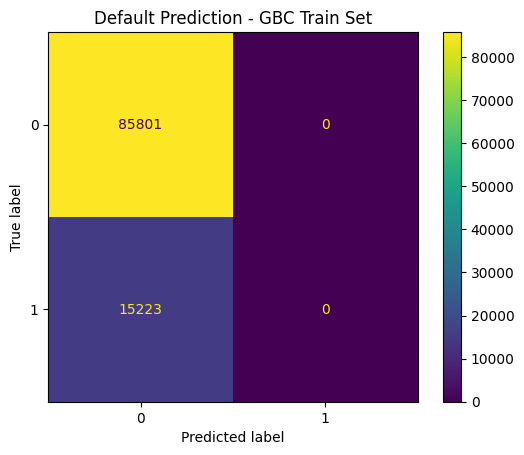

In [9]:
cm_train = confusion_matrix(y_train, y_train_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['0', '1'])
disp.plot()
plt.title("Default Prediction - GBC Train Set")
plt.grid(False)
plt.show()

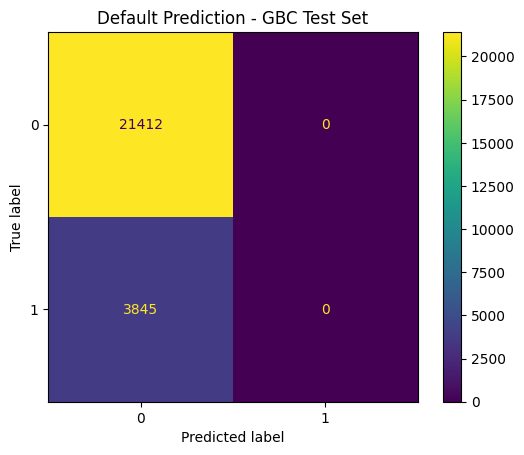

In [10]:
cm_test = confusion_matrix(y_test, y_test_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels= ['0', '1'])
disp.plot()
plt.title("Default Prediction - GBC Test Set")
plt.grid(False)
plt.show()

In [11]:
## Each tree is actually inside its own array within the list of estimators 
## from GBC
gbc.estimators_[0]

array([DecisionTreeRegressor(criterion='friedman_mse', max_depth=np.int64(2),
                             min_samples_leaf=np.int64(5),
                             random_state=RandomState(MT19937) at 0x28E74D140)],
      dtype=object)

In [12]:
gbc.estimators_[0][0]

DecisionTreeRegressor(criterion='friedman_mse', max_depth=np.int64(2),
                      min_samples_leaf=np.int64(5),
                      random_state=RandomState(MT19937) at 0x28E74D140)

/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without f

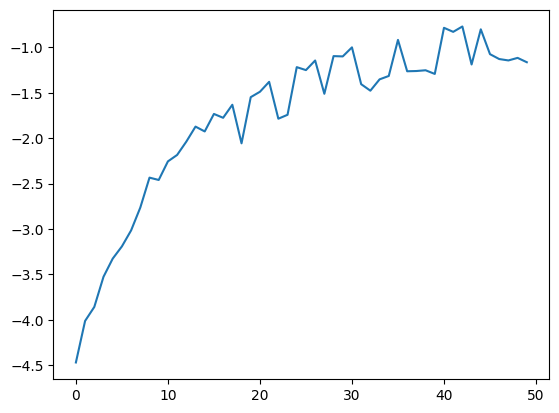

In [13]:
## We can actually look at each individual tree's score on the training set
## To see how it's contributing to the Loss Function
tree_scores = [t[0].score(X_train,y_train) for t in gbc.estimators_]
plt.plot(tree_scores)

In [14]:
gbc.predict_proba(X_train)

array([[0.86025908, 0.13974092],
       [0.86285403, 0.13714597],
       [0.86025908, 0.13974092],
       ...,
       [0.86025908, 0.13974092],
       [0.86285403, 0.13714597],
       [0.86285403, 0.13714597]], shape=(101024, 2))

In [15]:
train_prob = gbc.predict_proba(X_train)[:,1] ## This says For every row ':' give me the '1'th object, since we tend to only care about the probability of the positive class 
train_prob

array([0.13974092, 0.13714597, 0.13974092, ..., 0.13974092, 0.13714597,
       0.13714597], shape=(101024,))

<Axes: xlabel='Defaulted', ylabel='Count'>

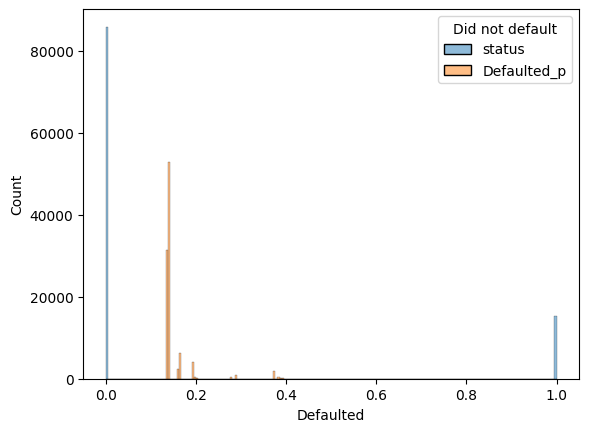

In [16]:
y_train_ = y_train.copy()
y_train_['Defaulted_p'] = train_prob
y_train_melt = pd.melt(y_train_,
                       value_vars= y_train_.columns.tolist(),
                       var_name = "Did not default",
                       value_name = "Defaulted")
sns.histplot(y_train_melt, x = 'Defaulted', hue = 'Did not default' )